# **Limitation of Euler's Method**

##1.
###**Limitations of the Euler’s method**:
So far, the Euler method has been used to solve
initial-value-problems numerically. In this lab session, some limitations of the method are
illustrated by means of examples.

*Airy Equation:*  Consider the equation,
$$\frac{d^2x}{dt^2}=tx(t)$$
$(a)$ Integrate the equation between $t=-30$ to $t=2$ by Euler’s method for number of
subdivisions $n = 1000, 3000, 5000, 10000$ . On the same graph(s), solve the initial value
problem using scipy’s inbuilt solve ivp solver (try the Radau method) or Matlab’s
ode15s (or similar).

$(b)$ Can you observe the difficulty in making the Euler method solution match closely with
the more accurate solution obtained using in-built solvers? This problem illustrates
the limitations of the Euler method and demonstrates why more sophisticated methods
are desirable.

##Hand Analysis


According to Euler's method, for a second order derivative:
$$x(t_o+h)=x(t_o)+h\cdot f(t_o,x_o)+v_o$$

We have been given the equation as:
$$\frac{d^2x}{dt^2}=tx(t)$$
Now we take different cases for t, as follows:

### Case 1: $t < 0$

When $t < 0$, write $t = -|t|$.  
Then the equation becomes:

$$
\frac{d^2 x}{dt^2} = -|t|\,x
$$

This resembles a harmonic oscillator:

$$
x'' + |t|x = 0
$$

So the solution is **oscillatory** in nature.


### Case 2: $t = 0$

At $t = 0$, the equation reduces to:

$$
\frac{d^2 x}{dt^2} = 0
$$

So locally the solution behaves like:

$$
x(t) = C_1 + C_2 t
$$

which is **linear**.


### Case 3: $t > 0$

When $t > 0$, the equation becomes:

$$
\frac{d^2 x}{dt^2} = t\,x
$$

or

$$
x'' - t x = 0
$$

In this region, the solution exhibits **exponential-type growth or decay**.

As $t$ increases, the growth becomes very rapid.

### Step Size Calculation

We are integrating from:

$$
t = -30 \quad \text{to} \quad t = 2
$$

So the total interval length is:

$$
2 - (-30) = 32
$$

If the number of subdivisions is $N$, then the step size is:

$$
h = \frac{2 - (-30)}{N} = \frac{32}{N}
$$



### Case 1: $N = 1000$

$$
h = \frac{32}{1000} = 0.032
$$



### Case 2: $N = 3000$

$$
h = \frac{32}{3000} \approx 0.01067
$$



### Case 3: $N = 5000$

$$
h = \frac{32}{5000} = 0.0064
$$



### Case 4: $N = 10000$

$$
h = \frac{32}{10000} = 0.0032
$$




## $(b)$
### Difficulty in Matching Euler Method with In-Built Solvers

Yes, it is difficult to make the Euler method closely match the more accurate solution obtained using in-built solvers.



### 1. Oscillatory Region ($t < 0$)

For $t < 0$, the equation behaves like:

$$
x'' + |t|x = 0
$$

This produces oscillatory solutions.

The Euler method:
- Does not conserve energy in oscillatory systems
- Introduces amplitude and phase errors
- Accumulates error over many steps

Since integration starts from $t = -30$, even small local errors build up significantly.



### 2. Long Integration Interval

The total interval length is:

$$
2 - (-30) = 32
$$

Euler’s global truncation error is:

$$
O(h)
$$

Because thousands of steps are used, small local errors accumulate continuously across the interval.

Reducing $h$ improves accuracy only linearly, which is slow.



### 3. Exponential Growth Region ($t > 0$)

For $t > 0$, the solution grows rapidly.

If the solution behaves like:

$$
x(t) \sim e^{\lambda t}
$$

then any small numerical error $\epsilon$ grows as:

$$
\epsilon e^{\lambda t}
$$

Thus:
- Small early errors become very large near $t = 2$
- The Euler solution visibly deviates from the accurate solution



### Conclusion

This demonstrates why higher-order and implicit solvers (such as Radau or ode15s) are preferable for solving the Airy equation.

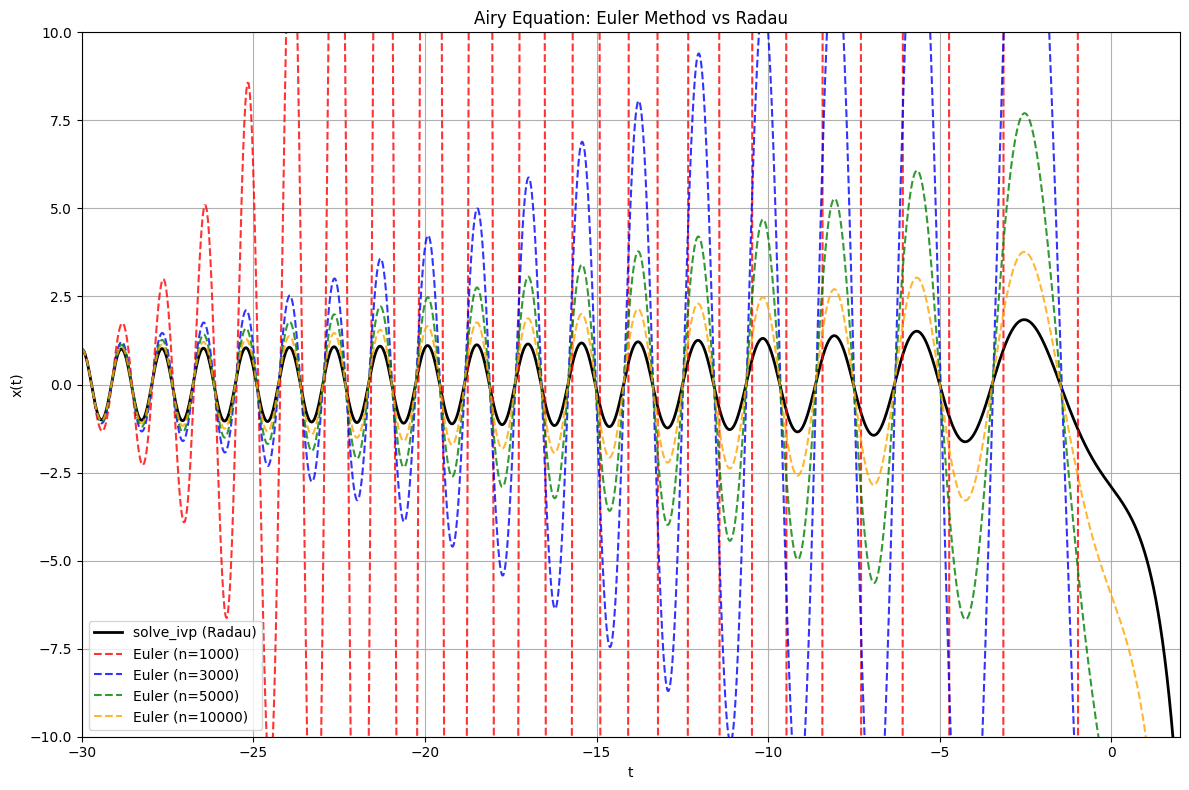

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def airy_system(t, y):
    return [y[1], t * y[0]]

def euler_method(f, t_span, y0, n):
    t0, tf = t_span
    t = np.linspace(t0, tf, n + 1)
    h = (tf - t0) / n
    y = np.zeros((len(y0), n + 1))
    y[:, 0] = y0

    for i in range(n):
        y_prime = np.array(f(t[i], y[:, i]))
        y[:, i + 1] = y[:, i] + h * y_prime

    return t, y

t_span = (-30.0, 2.0)
y0 = [1.0, 0.0]
n_values = [1000, 3000, 5000, 10000]

t_eval = np.linspace(t_span[0], t_span[1], 10000)
sol_radau = solve_ivp(airy_system, t_span, y0, method='Radau', t_eval=t_eval)

plt.figure(figsize=(12, 8))

plt.plot(sol_radau.t, sol_radau.y[0], 'k-', linewidth=2, label='solve_ivp (Radau)')

colors = ['red', 'blue', 'green', 'orange']
for n, color in zip(n_values, colors):
    t_euler, y_euler = euler_method(airy_system, t_span, y0, n)
    plt.plot(t_euler, y_euler[0], '--', color=color, alpha=0.8, label=f'Euler (n={n})')

plt.title("Airy Equation: Euler Method vs Radau")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.xlim(t_span[0], t_span[1])
plt.ylim(-10,10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##Observations
1. At lower number of subdivisions like $n=1000$ and $n=3000$, the Euler's method fails to completely bound the solution, greatly diverging from the Radau method solution.
2. Even at $n=10000$, the Euler's solution differs from the Radau's solution.Thus to make it overlap with Radau curve we need a huge number of subdivision making it computationally expensive.
3. The small difference between the n=5000 and n=10000 curves show a slow convergence rate. Hence, requiring large n to converge to Radau curve.

##Ques 2:
Consider the following equation,
$$\dot{x}=ax^2-bx^3,x(0)=δ$$
where δ is a small quantity.

$(a)$ Numerically integrate the above equation from $t = 0$ to $t=1.5/δ$ for $\delta=0.1, 0.01, 0.001$
and for $a = b = 1$.You should be seeing a sharp increase at around $\ t$~$δ^{-1}$,(i.e, this
point changes with δ). Do you have to decrease the step size for each successive δ to
obtain a smooth solution? If so, why?

$(b)$Why is the sudden increase occurring at t ∼ δ?

(Warning: This is a slightly challenging question. Think about this exercise in the
following way. You have done some numerical experiments/simulations on a system
provided to you and have a observed certain features. You are trying to explain
whether there is any theoretical reason behind these observations.

Think about the logistic equation, $\dot{x}=ax-bx^2$
, $x(0) = δ$. Do you see the region
where the “ramp”/increase occurs change with $δ$?

##Hand Analysis

We have been given the equation,
$$\dot{x} = ax^2-bx^3$$
Now, we have been given initial condition ie $x(0)=\delta$ and $\delta$ is a small quantity.

Now, near $x=0$, the $ax^2$ terms dominates and hence,
$$\dot{x} \approx ax^2$$

Now, we integrate and get
$$x(t) \approx \frac{\delta}{1 - a\delta t}$$
Now, when $t$ approaches $\frac{1}{a\delta}$, the denominator becomes zero.Hence, sudden growth is seen in the graph.


But, when $t$ approaches $\frac{1}{a\delta}$, the term $x(t)$ doesn't tend to $\infty$, rather it tends to $1$ as follow,

Now, $\dot{x}=0 \implies ax^2-bx^3=0 \implies x^2(a-bx)=0$
Hence, we get a solution at $x=a/b$, here $a=1,b=1$, hence the graph tends to $1$.


---


###Q. Do you have to decrease the step size for each successive δ to obtain a smooth solution? If so, why?
As $\delta$ gets smaller, the wait time increases, but the jump to the steady state remains extremely fast and steep. If the step size is too large, the math will overshoot the target ($x=1$), causing the simulation to oscillate wildly or blow up.

---
###Think about the logistic equation, ˙x = ax − bx2, x(0) = δ. Do you see the region where the “ramp”/increase occurs change with δ?

The logistic equation is $\dot{x} = ax - bx^2$.
* Logistic Growth: When $x$ is small, $\dot{x} \approx ax$. This leads to exponential growth ($x(t) = \delta e^{at}$). In this case, the time to reach the "ramp" depends on $\ln(1/\delta)$. This is a very "weak" dependence; even if you make $\delta$ much smaller, the time shift is small.
* Because the growth is $x^2$, the system has a finite-time singularity. The dependence on $\delta$ is $1/\delta$, which is "strong."



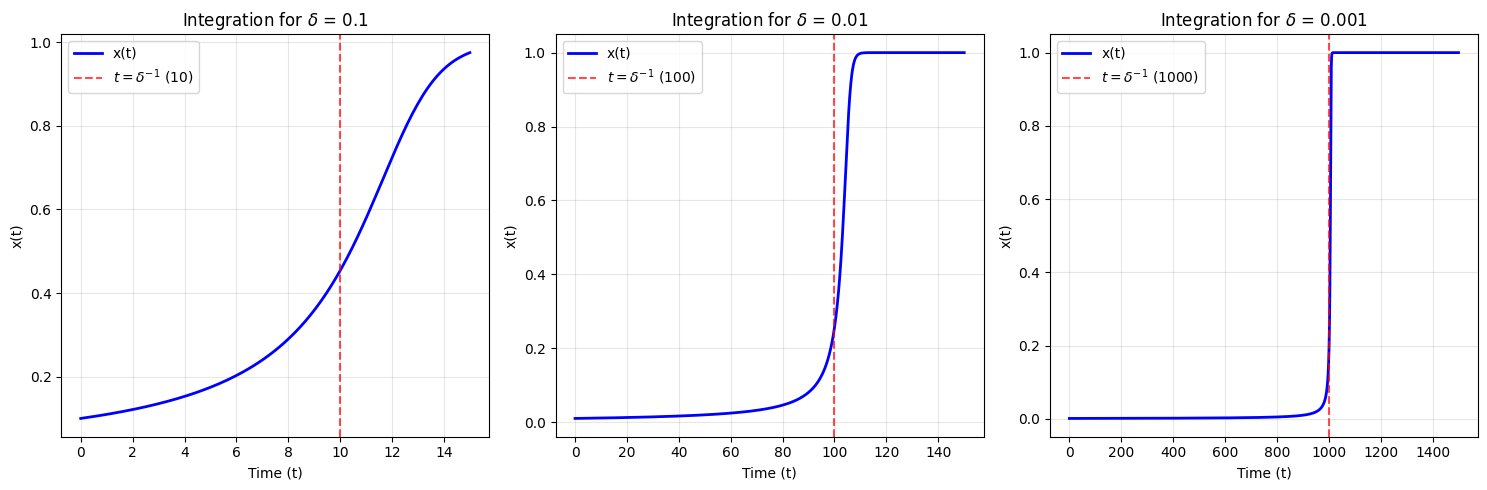

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def euler_integrate(delta, dt=0.1):
    t_max = 1.5 / delta
    n_steps = int(t_max / dt)

    t = np.linspace(0, t_max, n_steps)
    x = np.zeros(n_steps)
    x[0] = delta

    for i in range(1, n_steps):
        x[i] = x[i-1] + (x[i-1]**2 - x[i-1]**3) * dt

    return t, x

deltas = [0.1, 0.01, 0.001]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, delta in enumerate(deltas):
    t, x = euler_integrate(delta, dt=0.1)

    axes[i].plot(t, x, 'b-', linewidth=2, label='x(t)')
    axes[i].axvline(1/delta, color='r', linestyle='--', alpha=0.7, label=rf'$t = \delta^{{-1}}$ ({int(1/delta)})')

    axes[i].set_title(rf'Integration for $\delta$ = {delta}')
    axes[i].set_xlabel('Time (t)')
    axes[i].set_ylabel('x(t)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

##Observations
1. The curve moves slowly towards the time axis.But on encountering $t=δ^{-1}$ the curve shows a sharp rise whose steepness does not change on decreasing the value of $\delta$.
2. The transition or jump perfectly aligns with the vertical red dotted line. This shows a certain bottleneck where $x(t)$ is small for small values of $x<<1$ but shoots up for $x\gt1$
3. In each case after $x(t)$ shoots up, it gets stablized due to the presence of $x^3$ term which cancels out the effect of $x^2$ term, leading to a almost horizontal curve after $\delta^{-}$.
4. We don't need to decrease the step size for each successive $\delta$ as the steepness of the curve remains the same in each case.